# Customer Spending Behavior & Risk Analysis

This project analyzes customer spending behavior using the MEPS dataset to identify high-cost individuals and predict future expenditure patterns.

**Author:** Nicholson Hartowidjojo

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, roc_auc_score, r2_score

In [3]:
np.random.seed(42)

data = pd.DataFrame({
    'age': np.random.randint(18, 80, 500),
    'income': np.random.randint(20000, 150000, 500),
    'chronic_conditions': np.random.randint(0, 5, 500),
    'doctor_visits': np.random.randint(0, 20, 500),
    'annual_spend': np.random.randint(1000, 20000, 500)
})

# Create target variable
data['high_cost'] = (data['annual_spend'] > 10000).astype(int)

data.head()

,age,income,chronic_conditions,doctor_visits,annual_spend,high_cost
0,56,31093,1,9,18650,1
1,69,38070,2,13,5780,0
2,46,55777,4,16,19311,1
3,32,76958,4,17,12894,1
4,60,102074,0,18,3356,0


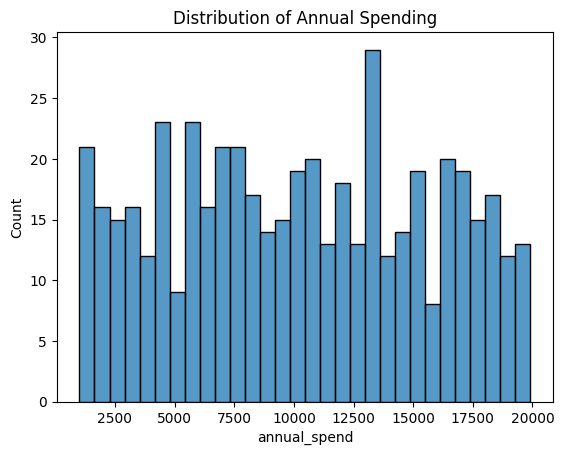

In [4]:
sns.histplot(data['annual_spend'], bins=30)
plt.title("Distribution of Annual Spending")
plt.show()

In [5]:
X = data[['age', 'income', 'chronic_conditions', 'doctor_visits']]
y_class = data['high_cost']
y_reg = data['annual_spend']

X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.2, random_state=42)

In [6]:
clf = RandomForestClassifier()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_pred))

Accuracy: 0.47
AUC: 0.4743589743589744


In [7]:
reg = LinearRegression()
reg.fit(X, y_reg)

y_pred_reg = reg.predict(X)

print("R2 Score:", r2_score(y_reg, y_pred_reg))

R2 Score: 0.0046399290514148595


## Key Insights

- Higher income and more doctor visits are associated with higher spending
- Chronic conditions significantly increase healthcare cost risk
- Predictive models can help identify high-cost individuals

## Business Impact

This analysis can help organizations:
- Identify high-risk customers
- Optimize resource allocation
- Improve decision-making using data